# Singapore Job Postings Salary Benchmarking Project

## Objective
Analyze salary data, clean outliers, and understand salary distribution trends in Singapore job postings.

## Task 1: Salary Data Cleaning & Outlier Handling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df = pd.read_csv("SGJobData.csv")
df.head()

,categories,employmentTypes,metadata_expiryDate,metadata_isPostedOnBehalf,metadata_jobPostId,metadata_newPostingDate,metadata_originalPostingDate,metadata_repostCount,metadata_totalNumberJobApplication,metadata_totalNumberOfView,...,occupationId,positionLevels,postedCompany_name,salary_maximum,salary_minimum,salary_type,status_id,status_jobStatus,title,average_salary
0,"[{""id"":13,""category"":""Environment / Health""},{...",Permanent,2023-05-08,False,MCF-2023-0252866,2023-04-08,2023-03-30,2,5,151,...,NaN,Executive,WORKSTONE PTE. LTD.,2800,2000,Monthly,0,Closed,Food Technologist - Clementi | Entry Level | U...,2400.0
1,"[{""id"":21,""category"":""Information Technology""}]",Permanent,2023-05-08,False,MCF-2023-0273977,2023-04-08,2023-04-08,0,0,55,...,NaN,Executive,TRUST RECRUIT PTE. LTD.,5500,4000,Monthly,0,Closed,"Software Engineer (Fab Support) (Java, CIM, Up...",4750.0
2,"[{""id"":33,""category"":""Repair and Maintenance""}]",Full Time,2023-04-22,False,MCF-2023-0273994,2023-04-08,2023-04-08,0,7,99,...,NaN,Senior Executive,PU TIEN SERVICES PTE. LTD.,4600,3800,Monthly,0,Closed,Senior Technician,4200.0
3,"[{""id"":21,""category"":""Information Technology""}]",Permanent,2023-05-08,False,MCF-2023-0273991,2023-04-08,2023-04-08,0,6,113,...,NaN,Senior Executive,TRUST RECRUIT PTE. LTD.,10000,5000,Monthly,0,Closed,"Senior .NET Developer (.NET Core, MVC, MVVC, S...",7500.0
4,"[{""id"":2,""category"":""Admin / Secretarial""}]",Full Time,2023-05-08,False,MCF-2023-0273976,2023-04-08,2023-04-08,0,3,99,...,NaN,Non-executive,EATZ CATERING SERVICES PTE. LTD.,3400,2400,Monthly,0,Closed,Sales / Admin Cordinator,2900.0


In [16]:
df.columns

Index(['categories', 'employmentTypes', 'metadata_expiryDate',
       'metadata_isPostedOnBehalf', 'metadata_jobPostId',
       'metadata_newPostingDate', 'metadata_originalPostingDate',
       'metadata_repostCount', 'metadata_totalNumberJobApplication',
       'metadata_totalNumberOfView', 'minimumYearsExperience',
       'numberOfVacancies', 'occupationId', 'positionLevels',
       'postedCompany_name', 'salary_maximum', 'salary_minimum', 'salary_type',
       'status_id', 'status_jobStatus', 'title', 'average_salary'],
      dtype='object')

In [26]:
df["salary"].isnull().sum()

0

## Missing Value Check

No missing values were found in the salary column. Therefore, no imputation or data filling was required.

In [19]:
df["salary"] = (df["salary_minimum"] + df["salary_maximum"]) / 2

In [20]:
df["salary"].describe()

count    1.048585e+06
mean     4.769445e+03
std      2.547809e+04
min      0.000000e+00
25%      2.900000e+03
50%      3.800000e+03
75%      5.500000e+03
max      1.266640e+07
Name: salary, dtype: float64

In [21]:
print("Before max:", df["salary"].max())

Before max: 12666400.0


In [22]:
lower = df["salary"].quantile(0.01)
upper = df["salary"].quantile(0.99)

df_clean = df[(df["salary"] >= lower) & (df["salary"] <= upper)]

In [23]:
print("After max:", df_clean["salary"].max())

After max: 16666.5


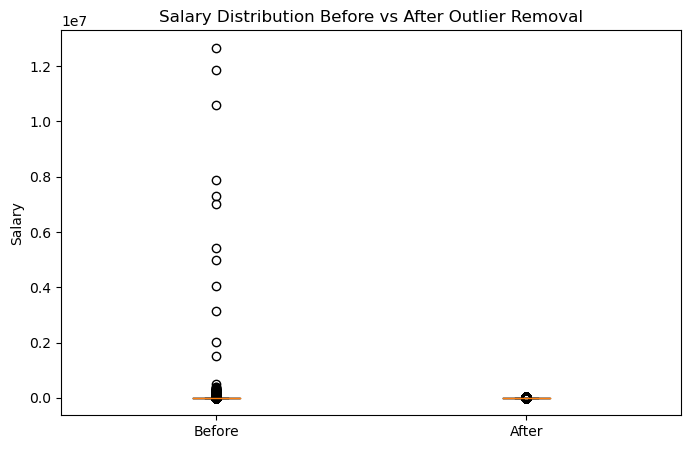

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.boxplot([df["salary"], df_clean["salary"]], labels=["Before", "After"])

plt.title("Salary Distribution Before vs After Outlier Removal")
plt.ylabel("Salary")
plt.show()

In [3]:
# IMPORTANT: assumed that df_clean contains the following, processed by the team

# df_clean contains:
# - primary_category (parsed)
# - positionLevels
# - minimumYearsExperience
# - outliers already handled
# - filtered dataset (agency/direct based on team decision)

df_clean.head()

,categories,employmentTypes,metadata_expiryDate,metadata_isPostedOnBehalf,metadata_jobPostId,metadata_newPostingDate,metadata_originalPostingDate,metadata_repostCount,metadata_totalNumberJobApplication,metadata_totalNumberOfView,...,occupationId,positionLevels,postedCompany_name,salary_maximum,salary_minimum,salary_type,status_id,status_jobStatus,title,average_salary
0,"[{""id"":13,""category"":""Environment / Health""},{...",Permanent,2023-05-08,False,MCF-2023-0252866,2023-04-08,2023-03-30,2,5,151,...,NaN,Executive,WORKSTONE PTE. LTD.,2800,2000,Monthly,0,Closed,Food Technologist - Clementi | Entry Level | U...,2400.0
1,"[{""id"":21,""category"":""Information Technology""}]",Permanent,2023-05-08,False,MCF-2023-0273977,2023-04-08,2023-04-08,0,0,55,...,NaN,Executive,TRUST RECRUIT PTE. LTD.,5500,4000,Monthly,0,Closed,"Software Engineer (Fab Support) (Java, CIM, Up...",4750.0
2,"[{""id"":33,""category"":""Repair and Maintenance""}]",Full Time,2023-04-22,False,MCF-2023-0273994,2023-04-08,2023-04-08,0,7,99,...,NaN,Senior Executive,PU TIEN SERVICES PTE. LTD.,4600,3800,Monthly,0,Closed,Senior Technician,4200.0
3,"[{""id"":21,""category"":""Information Technology""}]",Permanent,2023-05-08,False,MCF-2023-0273991,2023-04-08,2023-04-08,0,6,113,...,NaN,Senior Executive,TRUST RECRUIT PTE. LTD.,10000,5000,Monthly,0,Closed,"Senior .NET Developer (.NET Core, MVC, MVVC, S...",7500.0
4,"[{""id"":2,""category"":""Admin / Secretarial""}]",Full Time,2023-05-08,False,MCF-2023-0273976,2023-04-08,2023-04-08,0,3,99,...,NaN,Non-executive,EATZ CATERING SERVICES PTE. LTD.,3400,2400,Monthly,0,Closed,Sales / Admin Cordinator,2900.0


In [7]:
# first we calculate the midpoint_salary (midpoint between minimum and maximum salary)
# this is needed because job postings provides a salary range instead of a single number
# aim is to convert each job into a single comparable value
# make use of the midpoint between minimum and maximum salary to avoid biasing towards the minimum/maximum salary
df_clean["midpoint_salary"] = (
    df_clean["salary_minimum"] + df_clean["salary_maximum"]
) / 2

In [30]:
# Groups jobs by: Category (e.g. IT, Finance), Position level (e.g., Executive, Manager), Years of experience
# then compute the median salary for each group
# note that median is used instead of mean because high paying outliers can distort averages
# median is a good representation of the typical market salary for each group
# therefore we recommend salary based on the median of comparable roles (same category, level, and experience)
salary_table = df_clean.groupby(
    ["primary_category", "positionLevels", "minimumYearsExperience"]
)["midpoint_salary"].median().reset_index()
salary_table

,primary_category,positionLevels,minimumYearsExperience,midpoint_salary
0,Accounting / Auditing / Taxation,Executive,0,3000.0
1,Accounting / Auditing / Taxation,Executive,1,3250.0
2,Accounting / Auditing / Taxation,Executive,2,3400.0
3,Accounting / Auditing / Taxation,Executive,3,3750.0
4,Accounting / Auditing / Taxation,Executive,4,4100.0
...,...,...,...,...
4408,Wholesale Trade,Senior Management,9,9500.0
4409,Wholesale Trade,Senior Management,10,11750.0
4410,Wholesale Trade,Senior Management,12,13875.0
4411,Wholesale Trade,Senior Management,15,22500.0


In [ ]:
#create a function to get the midpoint_salary based on category, level and experience
def get_salary(category, level, experience):

    result = salary_table[
        (salary_table["primary_category"] == category) &
        (salary_table["positionLevels"] == level) &
        (salary_table["minimumYearsExperience"] == experience)
    ]

    if result.empty:
        return "No data available"

    return result["midpoint_salary"].values[0]

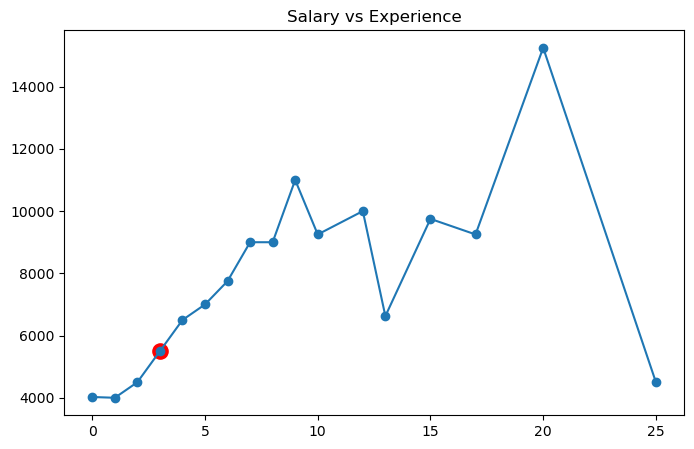

In [27]:
# visualize the relationship between experience and salary
# we want to show the salary structure of the market
trend = salary_table[
    (salary_table["primary_category"] == category) &
    (salary_table["positionLevels"] == level)
]

plt.figure(figsize=(8,5))
plt.plot(trend["minimumYearsExperience"], trend["midpoint_salary"], marker="o")

plt.scatter(
    experience,
    get_salary(category, level, experience),
    color="red",
    s=120
)

plt.title("Salary vs Experience")
plt.show()

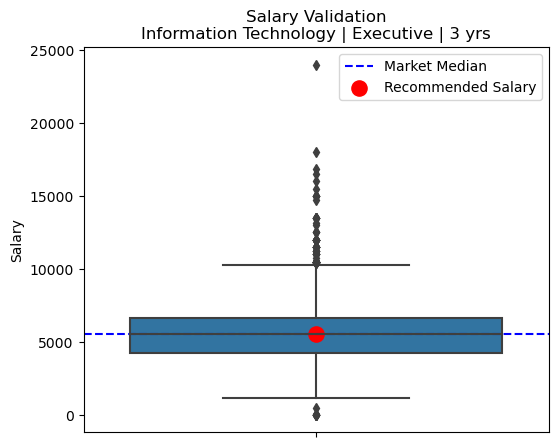

In [28]:
# Salary Validation Chart
# given one specific job context
# - the boxplot should show where most market salaries lies
# - what the median is
# - where our recommendation sits
# this chart is use to answer whether the recommended salary is reasonable and competitive in the market

category = "Information Technology"
level = "Executive"
experience = 3

# Selecting only job postings that match a specific role context
subset = df_clean[
    (df_clean["primary_category"] == category) &
    (df_clean["positionLevels"] == level) &
    (df_clean["minimumYearsExperience"] == experience)
]

# Market median (this is your recommended value logic)
recommended_salary = subset["midpoint_salary"].median()

plt.figure(figsize=(6,5))

# Boxplot = market distribution
sns.boxplot(y=subset["midpoint_salary"])

# Add market median line
plt.axhline(
    recommended_salary,
    color="blue",
    linestyle="--",
    label="Market Median"
)

# Add recommended salary point (same here, but explicit)
plt.scatter(
    0,
    recommended_salary,
    color="red",
    s=120,
    label="Recommended Salary"
)

plt.title(f"Salary Validation\n{category} | {level} | {experience} yrs")
plt.ylabel("Salary")
plt.legend()
plt.show()